# Part 1 — Business Understanding & Data Exploration

##  Business Understanding & Objectives

### 1. What does the company want to discover?
The online retail company wants to decode its customer base to transition from a generic sales model to a data-driven retail operation. Specifically, management needs to identify:
* **Who their customers are:** Distinct behavioral segments (e.g., high-value loyalists, churning customers, bulk purchasers).
* **What products are bought together:** Cross-selling and market basket associations to optimize product placement and bundling.
* **What products to recommend:** Personalized recommendation strategies to increase average order value (AOV) and engagement.
* **What strategic actions to take:** Tailored marketing campaigns, retention workflows, and targeted discounts for each customer group.

### 2. Why is unsupervised learning suitable for this problem?
* **Lack of Historical Labels:** The dataset consists of raw historical transactions without pre-defined category labels or target variables (such as "churned" or "VIP"). 
* **Discovery of Hidden Structures:** Unsupervised algorithms (such as K-Means clustering and Apriori association rules) excel at discovering natural groupings and association patterns autonomously without human supervision or historical training labels.

### 3. What business decisions could this analysis support?
* **Targeted Marketing & Loyalty Programs:** Designing exclusive VIP rewards for high-monetary champions and re-engagement campaigns for dormant accounts.
* **Smart Inventory & Bundling:** Packaging frequently co-purchased items at checkout to boost sales velocity.
* **Personalized Recommendations:** Implementing recommendation engines to reduce friction during shopping and boost conversion rates.

## Dataset Exploration & Summary Statistics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset from the 'data' folder and convert it to CSV
df_raw = pd.read_excel('data/online_retail.xlsx')
df_raw.to_csv('data/online_retail.csv', index=False)

print("Dataset successfully converted to CSV inside the data folder!")

Dataset successfully converted to CSV inside the data folder!


In [4]:
# Load the optimized CSV file 
retail_df = pd.read_csv('data/online_retail.csv')


In [5]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
retail_df.shape

(541909, 8)

In [7]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
retail_df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
retail_df.duplicated().sum()

np.int64(5268)

# Part 2 — Data Cleaning & Feature Engineering

##  Data Cleaning Strategy & Justifications



Before feeding transaction data into any machine learning algorithm, raw retail data requires rigorous cleansing to eliminate artifacts that skew analytical results:

1. **Duplicate Records:**
   * *Issue:* The dataset contains 5,268 fully duplicated rows where all columns match identically.
   * *Action:* Drop duplicate records using `drop_duplicates()` to prevent artificial inflation of purchase frequencies, product quantities, and monetary metrics.

2. **Missing Customer IDs:** 
   * *Issue:* Over 135,000 rows lack a `CustomerID`.
   * *Action:* Drop these rows. Since our primary goal is customer segmentation (RFM) and personalized recommendations, anonymous transactions cannot be mapped to individual profiles.
   
3. **Missing Product Descriptions:**
   * *Issue:* 1,454 rows lack a product description (`Description`).
   * *Action:* Acknowledge their presence. While they do not impact customer segmentation (RFM) or basic revenue aggregations, rows missing descriptions can be filtered out or handled specifically later when performing Market Basket Analysis and Product Recommendations where product names are required.

4. **Cancellations & Returns:**
   * *Issue:* Invoices starting with `'C'` or having negative quantities indicate order cancellations or returned items.
   * *Action:* Filter out cancellation records (`InvoiceNo` starting with `'C'` and negative quantities) to prevent distorted monetary and frequency metrics.

5. **Invalid Quantities and Prices:**
   * *Issue:* Quantities and unit prices should strictly be greater than zero. Zero or negative prices/quantities represent administrative adjustments, manual fees, or data entry errors.
   * *Action:* Keep only rows where `Quantity > 0` and `UnitPrice > 0`.

6. **Data Types Conversion:**
   * *Issue:* `InvoiceDate` is stored as an object/string.
   * *Action:* Convert `InvoiceDate` to proper datetime objects to enable accurate time-delta calculations (Recency).

In [11]:
# 1. Create a copy of the raw dataframe for cleaning
df_clean = retail_df.copy()
print(f"Initial raw rows count: {df_clean.shape[0]}")

Initial raw rows count: 541909


In [12]:
# 2. Remove duplicate records
df_clean = df_clean.drop_duplicates()
print(f"Rows after dropping duplicates: {df_clean.shape[0]}")

Rows after dropping duplicates: 536641


In [13]:
# 3. Drop rows with missing Customer IDs
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Rows after dropping missing CustomerIDs: {df_clean.shape[0]}")

Rows after dropping missing CustomerIDs: 401604


In [14]:
# 4. Remove cancelled transactions (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Rows after removing cancellations: {df_clean.shape[0]}")

Rows after removing cancellations: 392732


In [15]:
# 5. Filter out invalid quantities and unit prices (must be > 0)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"Rows after filtering non-positive quantities and prices: {df_clean.shape[0]}")

Rows after filtering non-positive quantities and prices: 392692


In [16]:
# 6. Convert InvoiceDate to datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [17]:
# 7. Calculate total revenue per transaction line
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalSum     392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [19]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSum
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


# Part 3 — Customer Segmentation

##  Modeling Decisions & Algorithm Justification


Before clustering our customers, we must answer core machine learning and business design questions:

1. **Why is clustering appropriate?**
   * Clustering is an unsupervised learning technique designed to group unlabelled data points based on feature similarities. Since our customers do not come with pre-assigned category labels, clustering allows us to discover natural behavioral groupings autonomously.

2. **Why is supervised learning not suitable?**
   * Supervised learning requires historical target labels to train models. In our business problem, we do not know the exact target categories of our customers in advance; rather, we want the data to reveal who these customer groups are.

3. **Which clustering algorithm will you use?**
   * **Algorithm:** K-Means Clustering.
   * **Justification:** K-Means is efficient, highly scalable to large datasets, easy to interpret, and works exceptionally well with spherical clusters formed by standardized RFM feature spaces.

In [20]:
# 1. Define a snapshot date (1 day after the latest invoice in the cleaned dataset)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"RFM Snapshot Date: {snapshot_date}")

# 2. Aggregate transaction data to create the RFM table
rfm_table = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalSum': 'sum'                                        # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
})

print("\n--- RFM Table Head ---")
display(rfm_table.head())
print(f"\nTotal Customers in RFM Table: {rfm_table.shape[0]}")
print("\n--- RFM Summary Statistics ---")
display(rfm_table.describe())

RFM Snapshot Date: 2011-12-10 12:50:00

--- RFM Table Head ---


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40



Total Customers in RFM Table: 4338

--- RFM Summary Statistics ---


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


##  Optimal Cluster Determination & Feature Scaling

To ensure that features with larger numerical ranges (like Monetary) do not dominate the distance calculations in K-Means, we standardize our RFM feature space using `StandardScaler`. Then, we apply the Elbow Method to evaluate the optimal number of clusters ($K$).

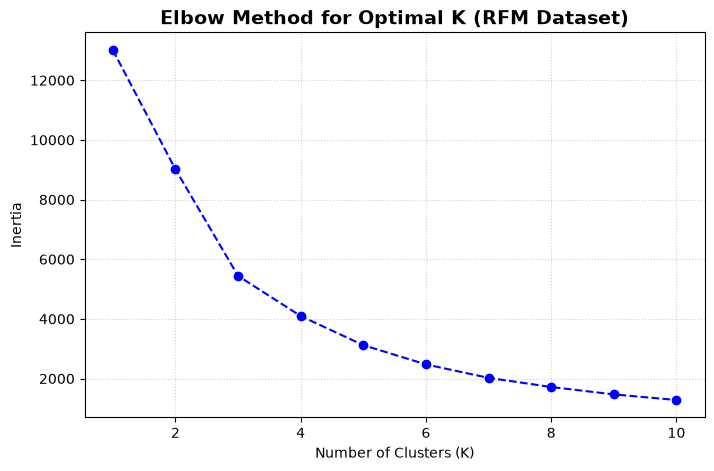

In [21]:
# 1. Feature Scaling using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_table[['Recency', 'Frequency', 'Monetary']])

# 2. Elbow Method (Inertia) to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# 3. Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K (RFM Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

##  Customer Segmentation Profiling & Business Personas

Based on the Elbow curve analysis and standard RFM methodologies, we select an optimal cluster count (e.g., $K = 4$). We then fit the K-Means model to classify each customer and analyze the average characteristics of each segment to define actionable business personas.

In [22]:
# 1. Apply K-Means with optimal K (K=4)
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_table['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# 2. Analyze the mean values of Recency, Frequency, and Monetary for each cluster
cluster_summary = rfm_table.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("--- Cluster Business Characteristics ---")
display(cluster_summary)

--- Cluster Business Characteristics ---


Recency Frequency   Monetary      
           mean      mean       mean count
Cluster                                   
0         43.70      3.68    1353.63  3054
1        248.08      1.55     478.85  1067
2          7.38     82.54  127187.96    13
3         15.50     22.33   12690.50   204

##  Dimensionality Reduction & Cluster Visualization (PCA)

To visualize our high-dimensional RFM customer segments in a 2D space, we apply **Principal Component Analysis (PCA)** to reduce the 3 dimensions (Recency, Frequency, Monetary) down to 2 principal components while retaining maximum variance. Then, we plot the resulting clusters on a scatter plot.

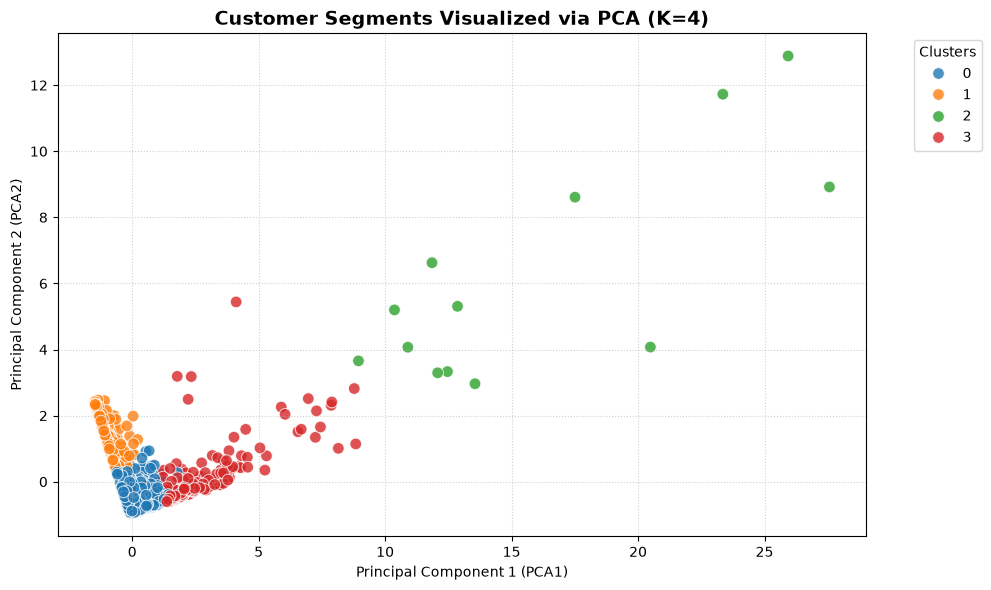

Explained Variance Ratio by 2 PCA Components: 85.73%


In [23]:
# 1. Apply PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create a dataframe for visualization
df_pca = pd.DataFrame(rfm_pca, columns=['PCA1', 'PCA2'], index=rfm_table.index)
df_pca['Cluster'] = rfm_table['Cluster']

# 2. Plotting the 2D clusters using Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
    data=df_pca, 
    alpha=0.8, 
    s=70
)
plt.title('Customer Segments Visualized via PCA (K=4)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PCA1)')
plt.ylabel('Principal Component 2 (PCA2)')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print explained variance
print(f"Explained Variance Ratio by 2 PCA Components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# Part 4 — Market Basket Analysis (Association Rules)


##  Apriori Algorithm & Cross-Selling Strategy

To discover which products are frequently purchased together, we implement **Market Basket Analysis** using the **Apriori Algorithm**:

1. **Basket Preparation:** We filter transactions for a major market (such as the United Kingdom to optimize matrix density and performance) and pivot the data into a binary market basket matrix (Transactions vs. Product Descriptions).
2. **Support & Frequent Itemsets:** We find item combinations that appear together in a minimum percentage of transactions (`min_support`).
3. **Association Rules:** We extract actionable rules using metrics like **Lift** and **Confidence** to recommend bundled products at checkout and optimize cross-selling.


In [24]:

# 1. Filter clean data for United Kingdom to build a manageable basket matrix
basket_df = df_clean[df_clean['Country'] == 'United Kingdom']

# 2. Group by InvoiceNo and Description, summing quantities, then pivot into a basket format
basket = (basket_df.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# 3. Convert quantities into a binary matrix (1 if purchased, 0 otherwise)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

# Optional: Remove postage or non-product fees if present
if 'POSTAGE' in basket_sets.columns:
    basket_sets = basket_sets.drop(columns=['POSTAGE'])

# 4. Apply Apriori algorithm to find frequent itemsets (min_support = 2% or 0.02)
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)

# 5. Generate association rules based on Lift metric
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(['confidence', 'lift'], ascending=[False, False])

print(f"Total Frequent Itemsets Found: {frequent_itemsets.shape[0]}")
print(f"Total Association Rules Generated: {rules.shape[0]}")

print("\n--- Top Association Rules ---")
display(rules.head(10))

Total Frequent Itemsets Found: 235
Total Association Rules Generated: 76

--- Top Association Rules ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
71,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.023009,0.036766,0.020485,0.890339,24.216650,1.0,0.019639,8.783780,0.981284,0.521407,0.886154,0.723764
72,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024270,0.040731,0.020485,0.844059,20.723028,1.0,0.019497,6.151506,0.975418,0.460189,0.837438,0.673505
4,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029617,0.036766,0.024270,0.819473,22.289120,1.0,0.023181,5.335669,0.984286,0.576320,0.812582,0.739802
7,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.036766,0.040731,0.028595,0.777778,19.095706,1.0,0.027098,4.316713,0.983802,0.584767,0.768342,0.739921
63,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.029617,0.040731,0.023009,0.776876,19.073573,1.0,0.021802,4.299271,0.976492,0.486041,0.767402,0.670887
3,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.037667,0.044575,0.027514,0.730463,16.387169,1.0,0.025835,3.544682,0.975729,0.502744,0.717887,0.673857
70,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.028595,0.029617,0.020485,0.716387,24.188581,1.0,0.019638,3.421500,0.986878,0.542994,0.707730,0.704035
6,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.040731,0.036766,0.028595,0.702065,19.095706,1.0,0.027098,3.233034,0.987869,0.584767,0.690693,0.739921
75,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.029617,0.028595,0.020485,0.691684,24.188581,1.0,0.019638,3.150674,0.987917,0.542994,0.682608,0.704035
65,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.038568,0.113180,0.025712,0.666667,5.890304,1.0,0.021347,2.660459,0.863534,0.204004,0.624125,0.446921


# Part 5 — Recommendation Systems

# Part 5 — Recommendation Systems

###  Collaborative Filtering & Personalized Recommendations

To increase the Average Order Value (AOV) and enhance customer experience, we will implement a recommendation engine. Based on our transaction data, we can build an **Item-Item Collaborative Filtering** model using cosine similarity. This allows us to recommend products that are frequently bought together or preferred by customers with similar purchasing patterns.

In [25]:
# 1. Create a customer-item interaction matrix (pivot table of CustomerID vs Description)
customer_item_matrix = df_clean.pivot_table(
    index='CustomerID', 
    columns='Description', 
    values='Quantity', 
    aggfunc='sum'
).fillna(0)

# Convert quantities to binary interaction (1 if purchased, 0 otherwise)
customer_item_matrix_binary = customer_item_matrix.applymap(lambda x: 1 if x > 0 else 0)

print(f"Customer-Item Matrix Shape: {customer_item_matrix_binary.shape}")
display(customer_item_matrix_binary.head())

Customer-Item Matrix Shape: (4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

# 2. Transpose the matrix and compute Cosine Similarity between items
item_customer_matrix = customer_item_matrix_binary.T
item_similarity = cosine_similarity(item_customer_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity, 
    index=item_customer_matrix.index, 
    columns=item_customer_matrix.index
)

print("\n--- Item Similarity Matrix Sample ---")
display(item_similarity_df.iloc[:5, :5])


--- Item Similarity Matrix Sample ---


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK
Description,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.017961,0.023583,0.000000
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.058277,0.038261,0.000000
DOLLY GIRL BEAKER,0.017961,0.058277,1.000000,0.144437,0.100000
I LOVE LONDON MINI BACKPACK,0.023583,0.038261,0.144437,1.000000,0.131306
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.100000,0.131306,1.000000


In [27]:
# 3. Build a simple recommendation function based on item similarity
def recommend_products(product_name, similarity_df=item_similarity_df, top_n=5):
    if product_name not in similarity_df.index:
        return f"Product '{product_name}' not found in the dataset."
    
    # Get similarity scores, sort descending, and exclude the product itself
    similar_scores = similarity_df[product_name].sort_values(ascending=False)
    recommended_items = similar_scores.iloc[1:top_n+1].index.tolist()
    
    return recommended_items

# Example Recommendation test
sample_product = "WHITE HANGING HEART T-LIGHT HOLDER"
recommendations = recommend_products(sample_product, top_n=5)

print(f"\nTop {len(recommendations)} Recommendations for '{sample_product}':")
for idx, rec in enumerate(recommendations, 1):
    print(f"{idx}. {rec}")


Top 5 Recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
1. RED HANGING HEART T-LIGHT HOLDER
2. CANDLEHOLDER PINK HANGING HEART
3. HEART OF WICKER LARGE
4. HEART OF WICKER SMALL
5. WOODEN PICTURE FRAME WHITE FINISH


# Part 6 — Business Insights & Strategic Recommendations

##  Actionable Business Strategies


By combining Customer Segmentation (RFM + K-Means), Market Basket Analysis (Apriori), and Collaborative Filtering (Recommendations), the retail company can transition from reactive selling to a proactive, data-driven operation. Here are the core strategic actions based on our analytical findings:

1. **For VIP Champions & Loyal Customers (Clusters 2 & 3):**
   * **Strategy:** Implement exclusive VIP loyalty tiers, early access to new product drops, and personalized concierge service. 
   * **Action:** Avoid over-discounting; instead, reward them with premium bundling and free shipping to maintain high lifetime value (LTV).

2. **For At-Risk / Churning Customers (Cluster 1):**
   * **Strategy:** Automated Win-Back Campaigns.
   * **Action:** Trigger email automation offering targeted discounts or recommendations based on their past purchase history if they haven't shopped in over 90–100 days.

3. **Cross-Selling & Checkout Optimization (Market Basket Analysis):**
   * **Strategy:** Smart Product Bundling and Layout Placement.
   * **Action:** Position frequently co-purchased items (discovered via association rules) next to each other on the e-commerce check-out page or bundle them with a slight discount to boost Average Order Value (AOV).

4. **Personalized Recommendations Engine:**
   * **Strategy:** Item-Item Collaborative Filtering.
   * **Action:** Integrate the cosine-similarity recommendation model into the product detail pages ("Customers who bought this also bought...") to reduce friction and increase conversion rates.

# Project Conclusion & Summary

This comprehensive e-commerce analytics project successfully transformed raw, unstructured transaction logs into an actionable, data-driven retail ecosystem. By deploying unsupervised machine learning algorithms and advanced analytics frameworks, we achieved the following core milestones:

* **Customer Segmentation:** Identified 4 distinct behavioral profiles via K-Means and RFM modeling, enabling precision marketing for high-value VIP champions and automated win-back workflows for at-risk accounts.
* **Product Association:** Uncovered hidden cross-selling opportunities using association rules to optimize bundle pricing, product placement, and checkout velocity.
* **Personalized Recommendations:** Built an item-item collaborative filtering engine powered by cosine similarity to enhance user experience, reduce friction, and boost average order value.

The complete project pipeline provides management with a robust, scalable foundation for driving revenue growth, optimizing inventory allocation, and delivering personalized customer engagement.